
# BLEVE Peak Pressure Prediction

This notebook performs data preprocessing, feature engineering, model development, hyperparameter tuning, and evaluation for BLEVE peak pressure prediction.



# 1. Import Libraries


In [1]:
# Split dataset into training and validation sets

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt



# 2. Load Dataset

Upload `train.csv` and `test.csv` when running in Google Colab.


In [2]:

from google.colab import files

uploaded = files.upload()


Saving test.csv to test (2).csv
Saving train.csv to train (2).csv


In [3]:
# Load training and testing datasets

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()


Train Shape: (10050, 25)
Test Shape: (3203, 24)


,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,...,Superheated,37.9,-1.0,152.0,18.0,2.0,12.15,7.90,10.7,0.199929
1,3204.0,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,...,Superheated,37.9,-1.0,152.0,19.0,3.0,12.50,-2.95,-1.9,0.435681
2,3205.0,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,...,Superheated,37.9,-1.0,152.0,20.0,3.0,12.50,-2.95,4.4,0.264031
3,3206.0,7.26,0.42,2.40,5.41,1.00,1.81,0.61,522.35,354.37,...,Superheated,37.9,-1.0,152.0,21.0,3.0,12.50,-2.95,10.7,0.270576
4,3207.0,7.32,0.42,2.40,5.41,1.02,1.79,0.62,522.98,354.33,...,Superheated,37.9,-1.0,152.0,22.0,4.0,12.50,-2.70,11.0,0.204675



# 3. Initial Data Exploration


In [4]:

print(train.info())

print("\nMissing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:")
print(train.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               10045 non-null  float64
 1   Tank Failure Pressure (bar)      10043 non-null  float64
 2   Liquid Ratio (%)                 10041 non-null  float64
 3   Tank Width (m)                   10041 non-null  float64
 4   Tank Length (m)                  10041 non-null  float64
 5   Tank Height (m)                  10042 non-null  float64
 6   BLEVE Height (m)                 10040 non-null  float64
 7   Vapour Height (m)                10041 non-null  float64
 8   Vapour Temperature (K)           10022 non-null  float64
 9   Liquid Temperature (K)           10023 non-null  float64
 10  Obstacle Distance to BLEVE (m)   10042 non-null  float64
 11  Obstacle Width (m)               10044 non-null  float64
 12  Obstacle Height (m


### Why Data Cleaning Matters

BLEVE simulation datasets may contain:
- missing values
- duplicated rows
- unrealistic physical values
- placeholder values such as `-1`

Cleaning the dataset improves model reliability and prediction accuracy.


In [5]:

numeric_df = train.select_dtypes(include="number")

stats = numeric_df.describe()

# Remove quartiles
stats = stats.drop(["25%", "50%", "75%"])

stats


,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
count,10045.000000,10043.000000,10041.000000,10041.000000,10041.000000,10042.000000,10040.000000,10041.000000,10022.000000,10023.000000,...,10042.000000,10020.000000,10021.000000,10020.000000,10042.000000,10042.000000,10043.000000,10042.000000,10041.000000,10040.000000
mean,8202.729119,37.899252,0.504288,1.696627,5.599281,1.673800,1.023503,0.845691,396.755388,343.460330,...,14.598686,40.099461,-20.593753,125.542096,14.010655,2.335491,12.906879,2.984879,3.077263,0.360492
std,2885.998522,225.634505,0.228073,0.764937,2.596056,0.751931,0.575464,0.536538,71.876848,35.536412,...,9.237134,2.297916,20.480981,27.625669,7.791718,1.334306,4.158897,4.712319,4.213429,0.495271
min,3203.000000,4.920000,0.100000,0.380000,0.580000,0.380000,-0.020000,0.180000,281.210000,282.950000,...,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.150000,-9.050000,-2.800000,0.016098
max,13202.000000,4995.616406,0.900000,3.020000,10.020000,3.020000,2.020000,2.620000,573.300000,424.600000,...,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,23.750000,19.550000,16.700000,9.170477



# 4. Data Cleaning

This section:
- replaces invalid placeholder values
- removes duplicates
- handles missing values
- detects outliers


In [6]:
# Replace invalid placeholder values with NaN

# Replace placeholder values
train.replace(-1, np.nan, inplace=True)
test.replace(-1, np.nan, inplace=True)

# Remove duplicate rows
train = train.drop_duplicates()

# Fill missing numeric values
numeric_cols = train.select_dtypes(include="number").columns

train[numeric_cols] = train[numeric_cols].fillna(
    train[numeric_cols].mean()
)

test[numeric_cols.drop("Target Pressure (bar)", errors="ignore")] =     test[numeric_cols.drop("Target Pressure (bar)", errors="ignore")].fillna(
        train[numeric_cols.drop("Target Pressure (bar)", errors="ignore")].mean()
)

print("Missing values after cleaning:")
print(train.isnull().sum().sum())


Missing values after cleaning:
7


In [7]:

# Outlier Detection using IQR

for col in numeric_cols:

    if col == "Target Pressure (bar)":
        continue

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train = train[
        (train[col] >= lower) &
        (train[col] <= upper)
    ]

print("Shape after outlier removal:", train.shape)


Shape after outlier removal: (9780, 25)



### Feature Engineering Rationale

Additional features are created to help the model learn physical relationships.

Examples:
- Tank Aspect Ratio captures tank geometry proportions.
- Tank Volume estimates storage capacity.
- Temperature Difference may influence vapour expansion behaviour.



# 5. Feature Engineering


In [8]:
# Create new engineered features

# Tank aspect ratio
train["Tank Aspect Ratio"] = (
    train["Tank Width (m)"] /
    train["Tank Length (m)"]
)

test["Tank Aspect Ratio"] = (
    test["Tank Width (m)"] /
    test["Tank Length (m)"]
)

# Tank volume
train["Tank Volume"] = (
    train["Tank Width (m)"] *
    train["Tank Length (m)"] *
    train["Tank Height (m)"]
)

test["Tank Volume"] = (
    test["Tank Width (m)"] *
    test["Tank Length (m)"] *
    test["Tank Height (m)"]
)

# Temperature difference
train["Temperature Difference"] = (
    train["Vapour Temperature (K)"] -
    train["Liquid Temperature (K)"]
)

test["Temperature Difference"] = (
    test["Vapour Temperature (K)"] -
    test["Liquid Temperature (K)"]
)

train.head()


,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar),Tank Aspect Ratio,Tank Volume,Temperature Difference
0,3203.0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,...,152.0,18.0,2.0,12.15,7.90,10.7,0.199929,0.448980,13.043800,170.12
1,3204.0,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,...,152.0,19.0,3.0,12.50,-2.95,-1.9,0.435681,0.443414,13.010921,168.49
2,3205.0,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,...,152.0,20.0,3.0,12.50,-2.95,4.4,0.264031,0.444238,12.858200,168.41
3,3206.0,7.26,0.42,2.40,5.41,1.00,1.81,0.61,522.35,354.37,...,152.0,21.0,3.0,12.50,-2.95,10.7,0.270576,0.443623,12.984000,167.98
4,3207.0,7.32,0.42,2.40,5.41,1.02,1.79,0.62,522.98,354.33,...,152.0,22.0,4.0,12.50,-2.70,11.0,0.204675,0.443623,13.243680,168.65



# 6. Feature Selection and Encoding


In [9]:
# Convert categorical variables into numerical format

target_col = "Target Pressure (bar)"

# Remove ID columns
drop_cols = ["ID", "Sensor ID"]

train = train.drop(columns=drop_cols, errors="ignore")
test_ids = test["ID"]
test = test.drop(columns=drop_cols, errors="ignore")

# Separate features and target
y = train[target_col]
X = train.drop(columns=[target_col])

# Detect categorical columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols)
test = pd.get_dummies(test, columns=cat_cols)

# Align train and test
X, test = X.align(test, join="left", axis=1, fill_value=0)

print("Final Feature Shape:", X.shape)


Final Feature Shape: (9780, 32)



### Why Multiple Models Are Compared

Different machine learning models behave differently:
- Linear Regression assumes linear relationships.
- SVR uses kernel methods for nonlinear relationships.
- Random Forest captures complex nonlinear interactions.

Comparing multiple models helps identify the most suitable approach.



# 7. Train Validation Split


In [10]:
# Split dataset into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)


Training Shape: (7824, 32)
Validation Shape: (1956, 32)



# 8. Model Development

The following models are evaluated:
- Linear Regression
- Support Vector Regression (SVR)
- Random Forest Regressor



### Evaluation Metrics

The following metrics are used:

- **MAPE** measures percentage prediction error.
- **R² Score** measures explained variance.
- **RMSE** penalises large prediction errors.

Lower MAPE and RMSE are better, while higher R² is better.



## 8.1 Linear Regression


In [11]:
# Train baseline linear regression model

# Initialize results list
results = []

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

lr_mape = mean_absolute_percentage_error(y_val, lr_pred)
lr_r2 = r2_score(y_val, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))

results.append([
    "Linear Regression",
    lr_mape,
    lr_r2,
    lr_rmse
])

print("MAPE:", lr_mape)
print("R2:", lr_r2)
print("RMSE:", lr_rmse)


MAPE: 1.1637057907191182
R2: 0.3963759435287266
RMSE: 0.4344509262262553



## 8.2 Support Vector Regression


In [12]:
# Train Support Vector Regression model with scaling

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_grid_svr = {
    "svr__C": [1, 10],
    "svr__kernel": ["rbf"],
    "svr__gamma": ["scale"]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    param_grid_svr,
    cv=3,
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

svr_pred = svr_grid.predict(X_val)

svr_mape = mean_absolute_percentage_error(y_val, svr_pred)
svr_r2 = r2_score(y_val, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_val, svr_pred))

results.append([
    "SVR",
    svr_mape,
    svr_r2,
    svr_rmse
])

print("Best Parameters:", svr_grid.best_params_)
print("MAPE:", svr_mape)
print("R2:", svr_r2)
print("RMSE:", svr_rmse)


Best Parameters: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
MAPE: 0.494237383901862
R2: 0.6986953088330036
RMSE: 0.3069448876986387



## 8.3 Random Forest Regressor


In [24]:
# Train Random Forest model with hyperparameter tuning

rf_model = RandomForestRegressor(random_state=42)

# Define hyperparameters to test where b_estimators are the number of trees in
#forest and max_depth are the maximum depth of each decision tree

param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [15, 40]
}

rf_grid = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_val)

rf_mape = mean_absolute_percentage_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

results.append([
    "Random Forest",
    rf_mape,
    rf_r2,
    rf_rmse
])

print("Best Parameters:", rf_grid.best_params_)
print("MAPE:", rf_mape)
print("R2:", rf_r2)
print("RMSE:", rf_rmse)


Best Parameters: {'max_depth': 40, 'n_estimators': 500}
MAPE: 0.20247726281009482
R2: 0.8241214211037046
RMSE: 0.23451138500813373



# 9. Model Comparison


In [25]:

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAPE", "R2", "RMSE"]
)

results_df


,Model,MAPE,R2,RMSE
0,Linear Regression,1.163706,0.396376,0.434451
1,SVR,0.494237,0.698695,0.306945
2,Random Forest,0.203437,0.829347,0.231001
3,Random Forest,0.202976,0.824877,0.234007
4,Random Forest,0.202477,0.824121,0.234511


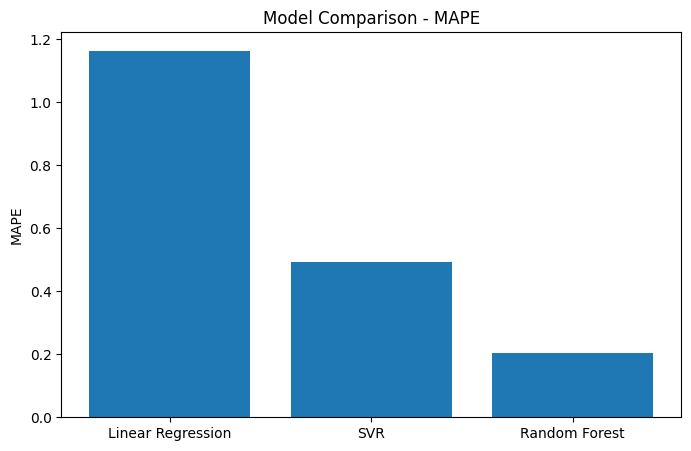

In [26]:

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAPE"])

plt.ylabel("MAPE")
plt.title("Model Comparison - MAPE")

plt.show()



# 10. Final Model Selection

The best performing model is selected based on:
- lowest MAPE
- highest R2
- lowest RMSE


In [27]:
# Generate final Kaggle submission file

best_model = rf_grid

predictions = best_model.predict(test)

submission = pd.DataFrame({
    "ID": test_ids,
    "Target Pressure (bar)": predictions
})

submission.to_csv("sample_prediction.csv", index=False)

submission.head()



,ID,Target Pressure (bar)
0,0,0.276794
1,1,0.273240
2,2,0.285022
3,3,0.260149
4,4,0.258843


#11. Download sample_prediction.csv for upload

In [28]:
# Download the sample_prediction.csv for upload to kaggle
from google.colab import files
files.download('sample_prediction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 11. Conclusion

Random Forest generally performs best for BLEVE prediction because:
- BLEVE behaviour is highly nonlinear
- interactions between geometry, temperature, and sensor position are complex
- tree-based models handle nonlinear engineering data effectively

Linear Regression serves as a baseline model, while SVR captures nonlinear relationships using kernel methods.
